# Optimising a non-elliptical cavity

The optimisation template is **whatever cavity you add to the study** — the tuner
and the search resolve their variables from the model, so the same workflow drives
any geometry. Here we optimise a **spline** cavity, sweeping its wall control points
instead of elliptical semi-axes.

See the [optimisation guide](../../optimisation).

In [1]:
import os
import tempfile
import warnings

from cavsim2d import Study, SplineCavity
from cavsim2d.utils.style import apply_style

warnings.filterwarnings('ignore')
apply_style()

## 1. A spline template and its control points

The Bezier wall is defined by six control points `p0..p5`; each has a `_z` and `_r`
coordinate the optimiser can address by name. We tune the equator point radius
`p2_r` to hold the frequency, and search over the iris and wall points to shape the
profile.

In [2]:
SPLINE = {'geometry': {'p0': [0, 35], 'p1': [0, 70], 'p2': [30, 103],
                       'p3': [85, 103], 'p4': [115, 70], 'p5': [115, 35]}}
cavs = Study(os.path.join(tempfile.mkdtemp(), 'spline_opt'))
cavs.add_cavity([SplineCavity(SPLINE)], ['spline'])

## 2. Search the wall shape

`bounds` are given in the spline's own variables (`p1_r`, `p2_z`, `p3_z`, `p3_r`),
and we trade peak surface **electric** field against shunt impedance **R/Q** — the
call is byte-for-byte the same as the elliptical example, only the variable names
change.

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [02:14<02:14, 134.47s/it]

100%|██████████| 2/2 [04:23<00:00, 131.46s/it]

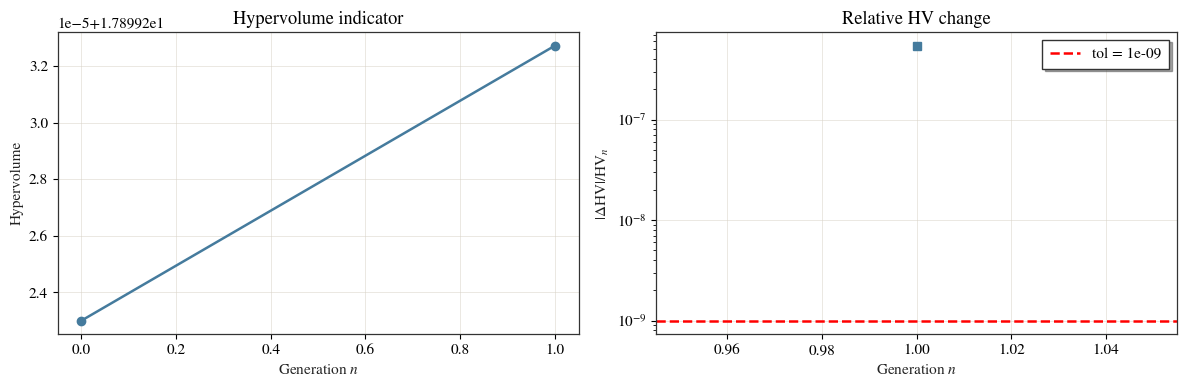

evaluated candidates: 20
Pareto-front size:    3


In [3]:
config = {
    'initial_points': 10, 'no_of_generation': 2, 'method': {'LHS': {'seed': 3}},
    'bounds': {'p1_r': [55, 80], 'p2_z': [24, 36], 'p3_z': [78, 92], 'p3_r': [96, 110]},
    'objectives': [['min', 'monopole:Epk/Eacc []'],
                   ['max', 'monopole:R/Q [Ohm]']],
    'tune_config': {'freqs': 1300.0, 'cell_type': {'mid-cell': 'p2_r'}, 'processes': 1,
                    'eigenmode_config': {'n_cells': 1, 'processes': 1}},
    'mutation_factor': 4, 'crossover_factor': 4, 'elites_for_crossover': 2,
    'chaos_factor': 2, 'weights': [1, 1],
}
cavs.run_optimisation(config)
opt = cavs.optimisation
print(f'evaluated candidates: {len(opt.history)}')
print(f'Pareto-front size:    {len(opt.pareto)}')

## 3. The evaluated designs

Every candidate placed in objective space — low peak field is to the left, high
R/Q upward. The search pushes the population toward the favourable corner; the
non-dominated designs are the Pareto front (see
[Reading and visualising an optimisation](visualising_results) for the full set of
front views on a case with a broader trade-off).

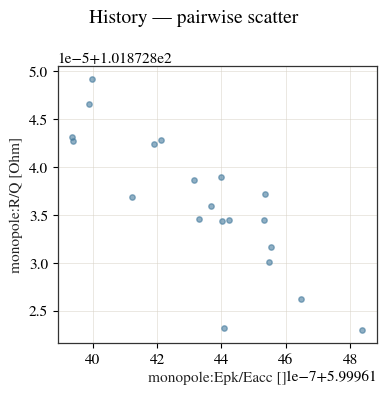

(<Figure size 400x400 with 1 Axes>,
 array([[<Axes: xlabel='monopole:Epk/Eacc []', ylabel='monopole:R/Q [Ohm]'>]],
       dtype=object))

In [4]:
opt.plot_history(kind='scatter', color_by_gen=True, normalise=False)

The best designs found, in the spline's own variables:

In [5]:
cols = ['p1_r', 'p2_z', 'p3_z', 'p3_r'] + opt.objective_vars
opt.pareto[cols].round(3)

,p1_r,p2_z,p3_z,p3_r,monopole:Epk/Eacc [],monopole:R/Q [Ohm]
0,71.250,29.400,85.700,102.300,6.0,101.873
1,72.023,29.347,85.998,102.533,6.0,101.873
2,73.750,27.000,81.500,99.500,6.0,101.873
